# Week 02 — Chance Operations and Controlled Randomness

*Algorithmic Generative Art with Python*

Last week chance drew lines for us; today we learn to *shape* chance — with distributions, weights, and seeds — and generate color-chart compositions in the spirit of Gerhard Richter and Ellsworth Kelly.

In [1]:
# OPTIONAL -- only for Google Colab: remove the leading '#' signs and run once.
# !git clone https://github.com/xysLong/algorithmic-generative-art-with-python.git
# %cd algorithmic-generative-art-with-python/notebooks

## Today's destination

A large Richter-style color grid: thousands of cells, colors drawn by weighted chance from a curated palette. Pure randomness plus two artistic decisions — *which* colors, and *how often* each may appear.

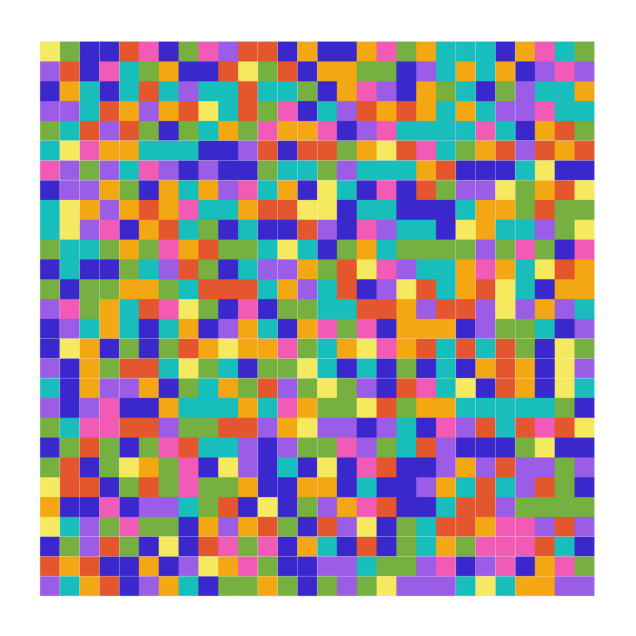

In [2]:
# display this week's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/week02_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: chance as anti-composition — and its return through the back door

Around 1916, in wartime Zurich, **Hans Arp** tore paper into scraps, let them fall onto a sheet, and glued them down where they landed: *Nach dem Gesetz des Zufalls* ("According to the Laws of Chance", 1916–17). For the Dadaists, chance was a weapon — against academic composition, against good taste, against a rationality that had just produced an industrial war. A few years earlier, **Marcel Duchamp** had already dropped three meter-long threads onto canvas and enshrined their curves as new "standard meters" (*3 stoppages étalon*, 1913–14): measurement itself handed over to accident.

The second wave was cooler and more systematic. **John Cage** composed *Music of Changes* (1951) by tossing coins and consulting the *I Ching* — chance not as rebellion but as a discipline for evading one's own preferences. That same year his friend **Ellsworth Kelly**, in Paris, arranged colored squares by drawing lots: *Spectrum Colors Arranged by Chance* (1951–53), grids whose serene, even glow looks anything but accidental. And from 1966 on, **Gerhard Richter** built his color charts from industrial paint-sample cards; the late culmination, *4900 Farben* (2007), is a machine-fair grid of 4900 lacquered squares whose arrangement was decided by a random number generator.

Here is the paradox to hold on to today: Arp used chance to *destroy* composition, yet Kelly's and Richter's chance-works are unmistakably composed. Where did the composing go? Into the **constraints**: Kelly chose the eighteen colors before chance touched anything; Richter fixed the palette, the grid, the format. Chance only ever filled in a form that taste had already built. When we replace uniform randomness with a *weighted* distribution, or jitter positions by a carefully tuned amount, we are doing exactly what they did — composing with the dials of probability. The artist does not disappear; the artist moves one level up.

That is why this session pairs the art history with a bit of probability theory. Distributions, weights, and clipping are not technical chores — they are, quite literally, the compositional tools of chance art.

## Two kinds of randomness

Not all randomness looks alike. A **uniform distribution** (Gleichverteilung) makes every value in a range equally likely — pure, flat chance. A **normal (Gaussian) distribution** (Normalverteilung) clusters values around a mean and makes extremes rare — chance with a preference. The histogram below shows 10,000 samples of each; the difference in shape is the difference between "anything goes" and "mostly this, sometimes that", and you will *see* it in the artworks later.

From this week on we also switch from the `random` module to **numpy**, the array library that powers the rest of the course.

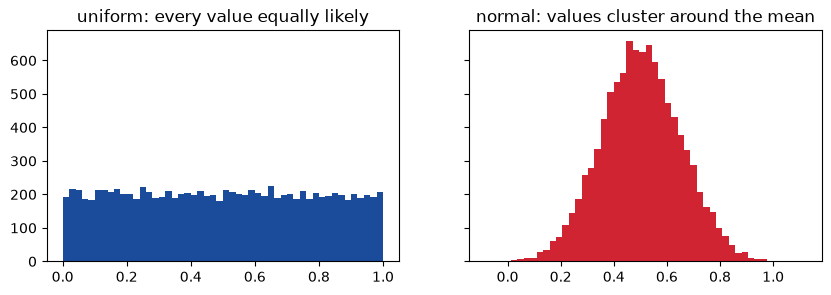

In [3]:
# 10,000 uniform vs 10,000 normal samples, compared as histograms
import numpy as np

rng = np.random.default_rng(42)
uniform_samples = rng.random(10_000)
normal_samples = rng.normal(0.5, 0.15, size=10_000)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].hist(uniform_samples, bins=50, color="#1B4B9B")
axes[0].set_title("uniform: every value equally likely")
axes[1].hist(normal_samples, bins=50, color="#D02433")
axes[1].set_title("normal: values cluster around the mean")
plt.show()

## Seeds: repeatable chance

The `rng` object above is a **random number generator**, created with a **seed** (`42`). A computer's randomness is *pseudo*-random: a deterministic formula that merely looks random. The seed is the formula's starting point — same seed, same sequence, forever and on every machine.

For generative artists this is a superpower, and it solves a real problem Cage had: he spent *nine months* tossing coins for *Music of Changes*, and no one can ever re-toss them. With a seed, a "chance" artwork becomes exactly reproducible: you can regenerate it at poster size, publish it as `seed=7`, or browse thousands of variants and *keep the address* of the one you love.

**Course convention from now on:** every notebook creates its randomness via `rng = np.random.default_rng(seed)`, and every generator function takes a `seed` parameter. All our seeds are fixed so the notebooks reproduce exactly — change any seed, any time, to make a piece your own. This is the one and only time we explain this; it holds for the rest of the semester.

In [4]:
# same seed -> same numbers; different seed -> different numbers
rng_a = np.random.default_rng(seed=7)
rng_b = np.random.default_rng(seed=7)
rng_c = np.random.default_rng(seed=8)

print("a:", rng_a.random(3))
print("b:", rng_b.random(3))
print("c:", rng_c.random(3))

a: [0.62509547 0.8972138  0.77568569]
b: [0.62509547 0.8972138  0.77568569]
c: [0.32697228 0.98727684 0.31871084]


## Weighted choice

Kelly drew his colors by lot, but nothing forces the lots to be fair. `rng.choice` accepts a probability per option (`p=...`) — the probabilities must add up to 1. This single idea is the difference between a color chart where every hue shouts equally and one with a quiet dominant tone and rare accents.

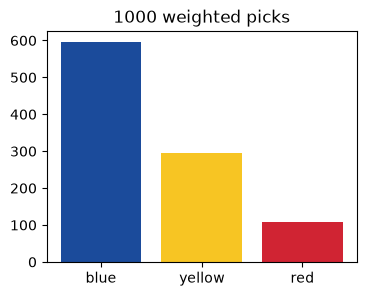

In [5]:
# weighted choice: blue common, yellow occasional, red rare
options = np.array(["blue", "yellow", "red"])
probabilities = [0.6, 0.3, 0.1]
rng = np.random.default_rng(1)
picks = rng.choice(options, size=1000, p=probabilities)

counts = []
for option in options:
    counts.append(np.sum(picks == option))

plt.figure(figsize=(4, 3))
plt.bar(options, counts, color=["#1B4B9B", "#F7C523", "#D02433"])
plt.title("1000 weighted picks")
plt.show()

## Keeping values on the canvas

Gaussian randomness has long tails: a jittered position can land outside the canvas, a jittered color value outside the legal range 0–1. `np.clip` fences values into a range — a small tool you will use constantly.

In [6]:
# clip: values below 0 become 0, values above 1 become 1
values = rng.normal(0.5, 0.4, size=8)
print("raw:    ", np.round(values, 2))
print("clipped:", np.round(np.clip(values, 0, 1), 2))

raw:     [0.2  0.1  0.85 0.61 0.94 0.88 0.4  0.17]
clipped: [0.2  0.1  0.85 0.61 0.94 0.88 0.4  0.17]


## Build-up: from garish to composed

We now build the color grid in five stages, adding one compositional decision at a time. Stage one: no decisions at all — every cell gets a completely random RGB color. An image, for numpy, is just an array of shape `(rows, cols, 3)`: three numbers (red, green, blue) per cell.

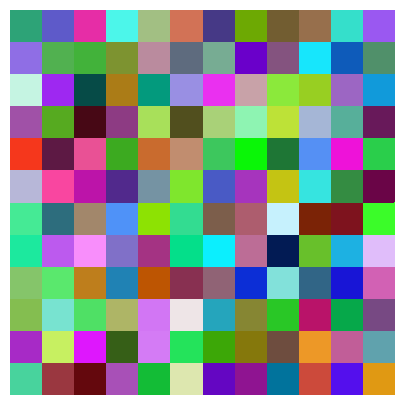

In [7]:
# stage 1: every cell a completely random RGB color
rng = np.random.default_rng(2026)
grid = rng.random((12, 12, 3))

plt.figure(figsize=(5, 5))
plt.imshow(grid)
plt.axis("off")
plt.show()

Garish, isn't it? Sixteen million colors, all equally likely, produce mud with sparks — what photographers call "clown vomit". No museum wall shows this. The first artistic decision is **curation**: restrict chance to a palette somebody chose. To use our course palettes we need one small converter, because they store colors as hex strings like `"#D02433"`.

In [8]:
# convert a hex color like '#D02433' into three numbers between 0 and 1
def hex_to_rgb(hex_color):
    r = int(hex_color[1:3], 16) / 255
    g = int(hex_color[3:5], 16) / 255
    b = int(hex_color[5:7], 16) / 255
    return (r, g, b)

print(hex_to_rgb("#D02433"))

(0.8156862745098039, 0.1411764705882353, 0.2)


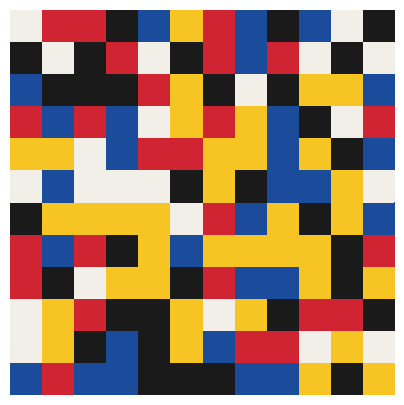

In [9]:
# stage 2: the same grid, but every cell picks from a fixed palette
import sys
sys.path.append("..")
from agap.helpers import PALETTES, save_artwork

palette = PALETTES["bauhaus"]
rng = np.random.default_rng(2026)

grid = np.zeros((12, 12, 3))
for row in range(12):
    for col in range(12):
        index = rng.integers(0, len(palette))
        grid[row, col] = hex_to_rgb(palette[index])

plt.figure(figsize=(5, 5))
plt.imshow(grid)
plt.axis("off")
plt.show()

Same code, same chance, same seed — only the *menu* changed, and suddenly it holds together. Remember the paradox from the context section: the composing moved into the constraints. Notice also that this is **authorship**: two students with different palettes get recognizably different works from identical algorithms.

Stage 3: not all colors deserve equal airtime. We give each palette color a weight — lots of near-black, a little cream, yellow as a rare event.

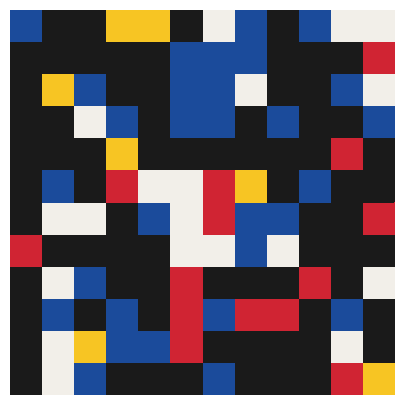

In [10]:
# stage 3: weighted palette -- a dominant tone and rare accents
weights = [0.15, 0.20, 0.05, 0.45, 0.15]   # one weight per bauhaus color
rng = np.random.default_rng(2026)

grid = np.zeros((12, 12, 3))
for row in range(12):
    for col in range(12):
        index = rng.choice(len(palette), p=weights)
        grid[row, col] = hex_to_rgb(palette[index])

plt.figure(figsize=(5, 5))
plt.imshow(grid)
plt.axis("off")
plt.show()

Stage 4: so far the *colors* are random but the *geometry* is rigid. Now we jitter positions and sizes with small Gaussian nudges (`rng.normal(0, jitter)`), so the grid trembles like something laid out by hand. For that we leave `imshow` and draw each cell as a `Rectangle` — remember drawing shapes one by one from last week's squares.

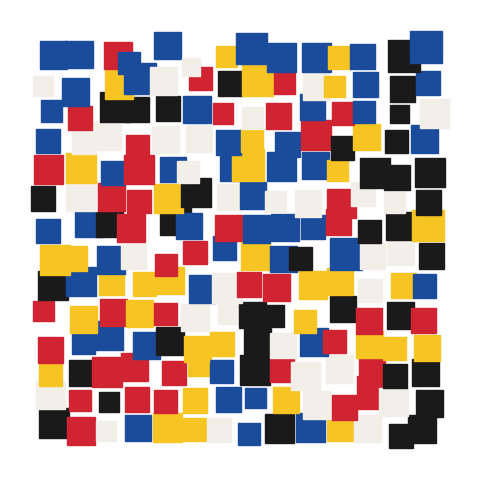

In [11]:
# stage 4: a hand-trembled grid -- positions and sizes jittered
from matplotlib.patches import Rectangle

rng = np.random.default_rng(11)
jitter = 0.12

fig, ax = plt.subplots(figsize=(6, 6))
for row in range(14):
    for col in range(14):
        x = col + rng.normal(0, jitter)
        y = row + rng.normal(0, jitter)
        size = 0.9 + rng.normal(0, jitter)
        index = rng.integers(0, len(palette))
        ax.add_patch(Rectangle((x, y), size, size, color=palette[index]))

ax.set_xlim(-1, 15)
ax.set_ylim(-1, 15)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

Stage 5: chance can also ride on top of a *gradient*. In Kelly's spectrum panels, hue drifts systematically across the surface while chance roughens the order. We build colors in **HSV** (hue–saturation–value), let the hue follow the column index, and add Gaussian noise to it. Hue lives on a color *wheel*, so instead of clipping we **wrap** with the modulo operator `% 1.0` — clip fences a line, modulo closes a circle.

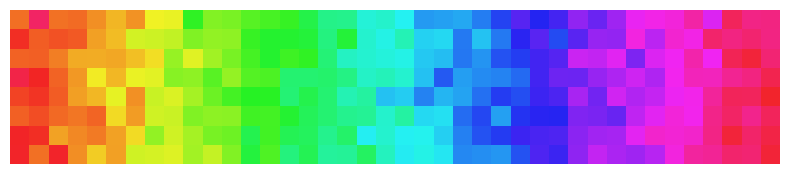

In [12]:
# stage 5: Kelly-style spectrum -- hue drifts left to right, chance roughens it
import colorsys

rng = np.random.default_rng(3)
rows = 8
cols = 40

grid = np.zeros((rows, cols, 3))
for row in range(rows):
    for col in range(cols):
        hue = col / cols + rng.normal(0, 0.03)
        hue = hue % 1.0                      # hues wrap around the color wheel
        r, g, b = colorsys.hsv_to_rgb(hue, 0.85, 0.95)
        grid[row, col] = (r, g, b)

plt.figure(figsize=(10, 2))
plt.imshow(grid)
plt.axis("off")
plt.show()

## Playground

The finished generator, all decisions as parameters: grid size, palette, weights (or `None` for fair chance), jitter, seed. Below it is called four times with very different temperaments — and if your environment supports it, a slider version.

In [13]:
# the finished generator: a chance color grid in the Richter/Kelly tradition
def color_grid(rows=20, cols=20, palette_name="bauhaus", weights=None,
               jitter=0.0, seed=1):
    palette = PALETTES[palette_name]
    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(figsize=(7, 7 * rows / cols))
    for row in range(rows):
        for col in range(cols):
            x = col + rng.normal(0, jitter)
            y = row + rng.normal(0, jitter)
            size = 0.92 + rng.normal(0, jitter)
            if weights is None:
                index = rng.integers(0, len(palette))
            else:
                index = rng.choice(len(palette), p=weights)
            ax.add_patch(Rectangle((x, y), size, size, color=palette[index]))
    ax.set_xlim(-1, cols + 1)
    ax.set_ylim(-1, rows + 1)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

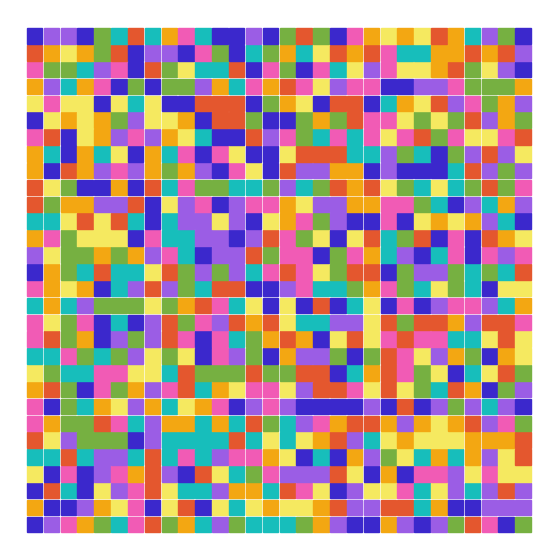

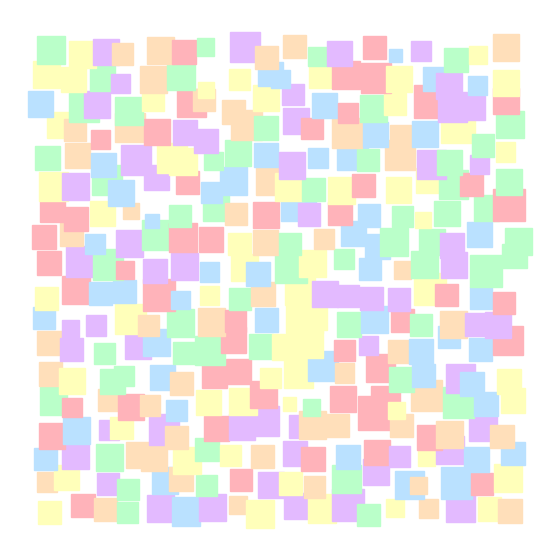

In [14]:
# temperament 1 and 2: strict Richter grid vs trembling pastel
art_1 = color_grid(rows=30, cols=30, palette_name="kelly", seed=8)
art_2 = color_grid(rows=18, cols=18, palette_name="pastel", jitter=0.15, seed=2)

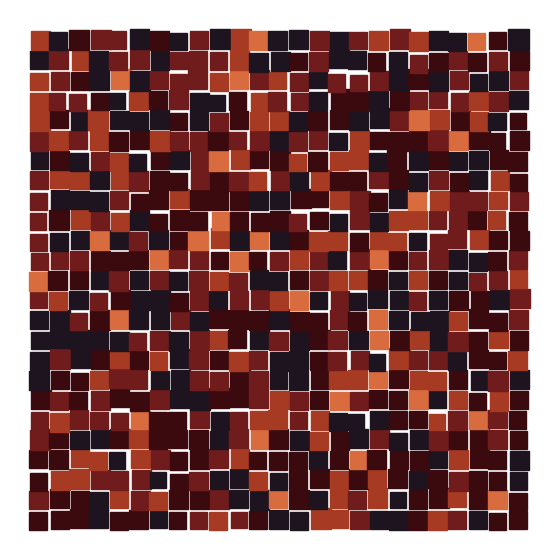

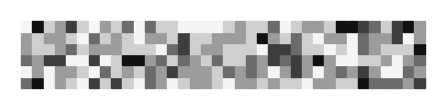

In [15]:
# temperament 3 and 4: dark and weighted vs a quiet monochrome frieze
art_3 = color_grid(rows=25, cols=25, palette_name="rothko_dark",
                   weights=[0.30, 0.25, 0.15, 0.05, 0.25], jitter=0.04, seed=5)
art_4 = color_grid(rows=6, cols=36, palette_name="monochrome",
                   weights=[0.05, 0.10, 0.15, 0.25, 0.25, 0.20], seed=13)

**Look and compare.** Which of the four feels calmest? Which parameter is responsible — the palette, the weights, or the jitter? Note that `art_3` uses *both* weights and jitter: cover one eye and ask yourself which of the two carries more of its mood. And why does the wide format of `art_4` alone change how you read it?

In [16]:
# optional sliders -- everything they do, the plain function calls above do too
try:
    from ipywidgets import interact, fixed
    interact(color_grid, rows=(4, 40), cols=(4, 40),
             palette_name=list(PALETTES.keys()), weights=fixed(None),
             jitter=(0.0, 0.4, 0.02), seed=(0, 100))
except ImportError:
    print("ipywidgets is not installed -- use the plain function calls above")

interactive(children=(IntSlider(value=20, description='rows', max=40, min=4), IntSlider(value=20, description=…

## Export your artwork

Tune the parameters until the grid feels like yours, replace `yourname`, run the cell — the print-quality PNG lands in `assets/outputs/`.

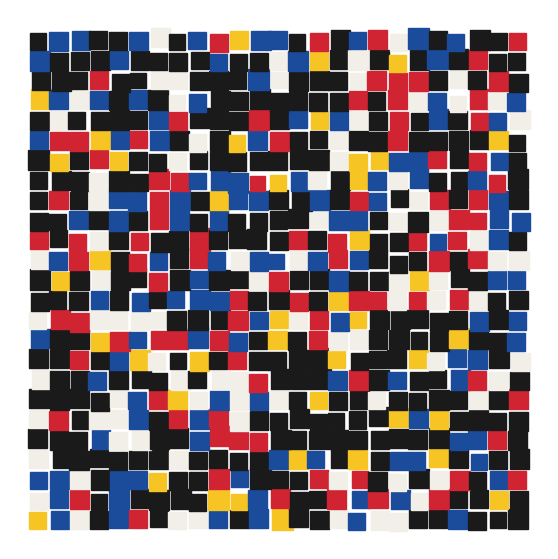

saved: assets/outputs/week02_yourname.png


In [17]:
# save YOUR artwork: adjust parameters, replace 'yourname', run the cell
my_artwork = color_grid(rows=25, cols=25, palette_name="bauhaus",
                        weights=[0.15, 0.20, 0.05, 0.45, 0.15],
                        jitter=0.05, seed=2026)
saved_path = save_artwork(my_artwork, "yourname", week=2)

## Exercises

**(a) Parameter exploration — the threshold of design.** Run `color_grid` with `jitter` at 0.0, 0.05, 0.1, 0.2, 0.3 and 0.4 (same seed each time). Somewhere in that range the grid stops feeling "designed" and starts feeling broken. Where is that threshold for you? Compare with your neighbor — is it the same value? What does that say about where the artwork happens: in the code or in the eye?

**(b) Code modification — Richter's rule.** For *4900 Farben*, Richter noticed that pure chance produces clumps of same-colored neighbors — and viewers read clumps as *intent*. Implement the constraint: **no two horizontally adjacent cells may share a color.** Start from the stage-2 grid code (the `imshow` version is easier than the Rectangle version): remember the previous cell's color index, and re-draw while the new index equals it.

<details><summary>Solution</summary>

```python
def color_grid_no_repeat(rows=20, cols=20, palette_name="bauhaus", seed=1):
    palette = PALETTES[palette_name]
    rng = np.random.default_rng(seed)
    grid = np.zeros((rows, cols, 3))
    for row in range(rows):
        previous_index = -1                       # no color yet in this row
        for col in range(cols):
            index = rng.integers(0, len(palette))
            while index == previous_index:        # forbidden? draw again
                index = rng.integers(0, len(palette))
            grid[row, col] = hex_to_rgb(palette[index])
            previous_index = index
    plt.figure(figsize=(6, 6))
    plt.imshow(grid)
    plt.axis("off")
    plt.show()

color_grid_no_repeat()
```

The `while` loop simply re-rolls the dice until the constraint is satisfied — the standard trick for "chance, but not *that*". (Richter's printed edition of *4900 Farben* used essentially this rule for adjacent panels.)
</details>

**(c) Creative challenge — your own chance operation.** Squares are only one vocabulary. Compose a chance work from a different element: dots of random size, short lines at random angles, or letters drawn from your own name. Keep the two Kelly/Richter decisions — a curated palette and a deliberate weighting — and give the piece a title in the Dada spirit.

## Further reading

- Herbert Molderings, *Duchamp and the Aesthetics of Chance* (Columbia UP, 2010) — chapter 1 on the *3 Standard Stoppages* as an "experiment in chance".
- Gerhard Richter, [*4900 Colours*](https://gerhard-richter.com/en/art/microsites/4900-colours) — the artist's own microsite; look at the versioning system (the work can be hung in 11 different configurations).
- Ellsworth Kelly on the Paris chance works: [*Spectrum Colors Arranged by Chance*, MoMA](https://www.moma.org/collection/works/37202) — collection entry with the artist's account of the lottery procedure.
- Technical: the [numpy random generator documentation](https://numpy.org/doc/stable/reference/random/generator.html) — skim `random`, `normal`, `choice`, `integers`; these four methods carry the whole course.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook. It runs automatically with *Restart & Run All*.

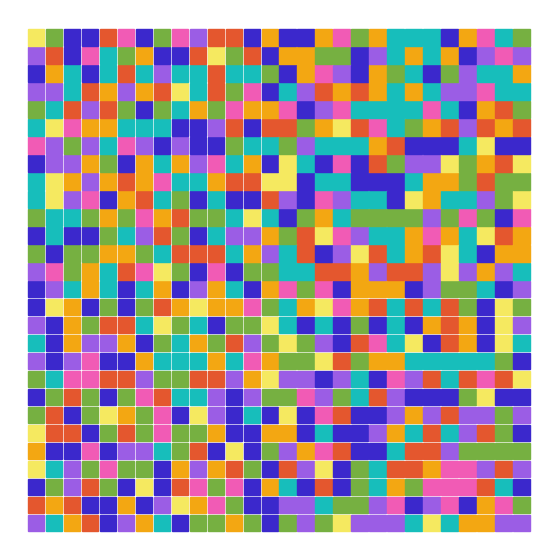

saved: assets/outputs/week02_showpiece.png


In [18]:
# regenerate this week's showpiece: a large weighted Richter-style grid
showpiece = color_grid(rows=28, cols=28, palette_name="kelly",
                       weights=[0.10, 0.14, 0.06, 0.16, 0.16, 0.18, 0.10, 0.10],
                       jitter=0.0, seed=4900)
saved_path = save_artwork(showpiece, "showpiece", week=2)